<a href="https://colab.research.google.com/github/elvispreakerebi/ml-pipeline-formative-1/blob/nformi/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1: Time series preprocessing and exploratory analysis

#A: Understanding the dataset
In this section, we will load the dataset, check its basic properties, handle any missing values, and explore the statistical distributions of our numerical features

In [29]:
#environmental setup and importing all nccessary libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
#from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)

In [3]:
from google.colab import drive #mounting the drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/Ecommerceformative

'archive (6).zip'


In [5]:
!unzip -o '/content/drive/MyDrive/Ecommerceformative/archive (6).zip' -d /content/data

Archive:  /content/drive/MyDrive/Ecommerceformative/archive (6).zip
  inflating: /content/data/ecommerce_sales_data.csv  


In [6]:
!ls /content/data

ecommerce_sales_data.csv


In [7]:
#loading the data
pd.read_csv('/content/data/ecommerce_sales_data.csv')

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [8]:
df = pd.read_csv('/content/data/ecommerce_sales_data.csv')
df.info() #checkong for null values and basic checks

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


**observation and data cleaning strategy**: dataset looks good, with no null values all 3500 entries are non-null values bu the order date column needs needs to be converted to datetime format.

**handling missing values**: after forcing continuous daily frequency(asfreq('D)), some dates may appear with missing values (NANs), this happens because there simply are no recorded transactions for that specific day/days. so, there most lodical and accurate methodology is to fill these missing values with 0, representing zero sales, quantity and profit for those inactive days.

In [39]:
#converting the order date to date and time
df['Order Date'] = pd.to_datetime(df['Order Date'])

#aggregating to daily level
daily_df = df.resample('D', on='Order Date').agg(
    {
        'Sales': 'sum',
        'Quantity': 'sum',
        'Profit': 'sum'
    }
)

#ensuring that there is continuous daily date index
daily_df=daily_df.asfreq('D')

#checking for time range and frequency
print('start date:', daily_df.index.min())
print('end date:', daily_df.index.max())
print('total daya:', len(daily_df))
print('frequency: Daily')

#statistical overview of the numerical data/ DataFrame containing count, mean, standard deviation
display(daily_df.describe())


start date: 2022-01-01 00:00:00
end date: 2024-12-31 00:00:00
total daya: 1096
frequency: Daily


,Sales,Quantity,Profit
count,1096.000000,1096.000000,1096.000000
mean,9733.468066,15.749088,1683.088695
std,6865.093291,9.999817,1290.195183
min,0.000000,0.000000,0.000000
25%,4726.000000,8.000000,722.807500
50%,8627.000000,14.000000,1431.865000
75%,13394.250000,22.000000,2337.402500
max,44063.000000,60.000000,7231.530000


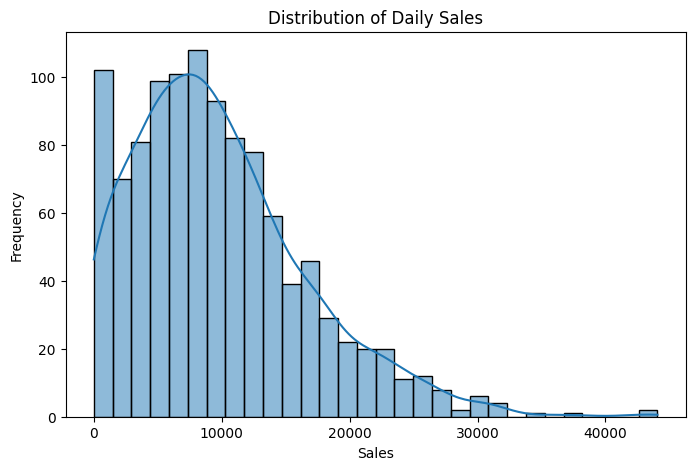

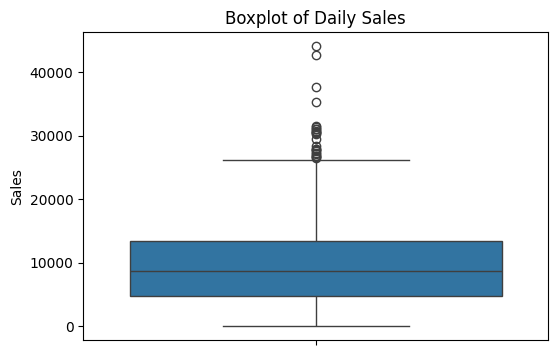

In [42]:
#sales distribution histogram
plt.figure(figsize=(8,5))
sns.histplot(daily_df['Sales'], bins=30, kde=True)
plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


#boxplot for outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=daily_df['Sales'])
plt.title("Boxplot of Daily Sales")
plt.show()

**interpretation of distribution:**
the **histogram** is indicating that daily sales are right-skewed, meaning that whilw the most days cluster around a lower-medium sales volume(roughly 5000-15000), there is a long tail of dails with exceptionaly high sales.

the **boxplot** confirsms this, by showing several outlier points abpve the upper whisker(past 25000). These are likely promotiona days, holidays, or orders in bulk

#**Analytical** **Questions**

#Question 1:
**what is the overall, longterm trend for daily sales?**

to answer this, we will plot the daily sales alongside a 30day moving average to smooth out the daily noise and reveal the underlying trend

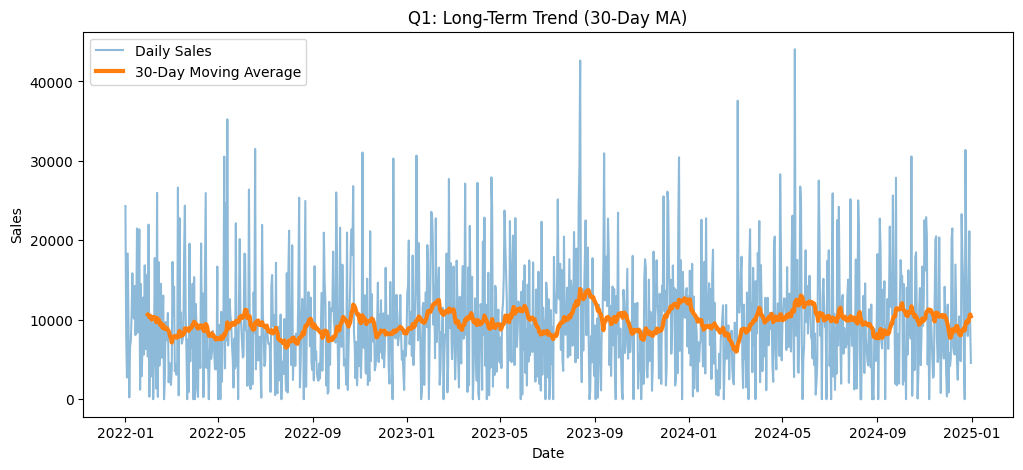

In [43]:
#calculating the 30-day moving average
daily_df['MA_30'] = daily_df['Sales'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_df['Sales'], label='Daily Sales', alpha=0.5)
plt.plot(daily_df['MA_30'], label='30-Day Moving Average', linewidth=3)
plt.legend()
plt.title("Q1: Long-Term Trend (30-Day MA)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**Interpretation**: the 30-day moving average effectively smooths the highly eratic daily sales data. we can observe distinct macroeconomic waves in the business, with peaks likely correcponding to seasonal high-demand periods. the overall trend remains relevantly stable over the years, without a dramatic , permenent upward or downwad trajectory

#Question 2

**Are there prominent short-term trends or weekly patterns in the data?**
we will use the 7day moving average to capture localized week-week momentum

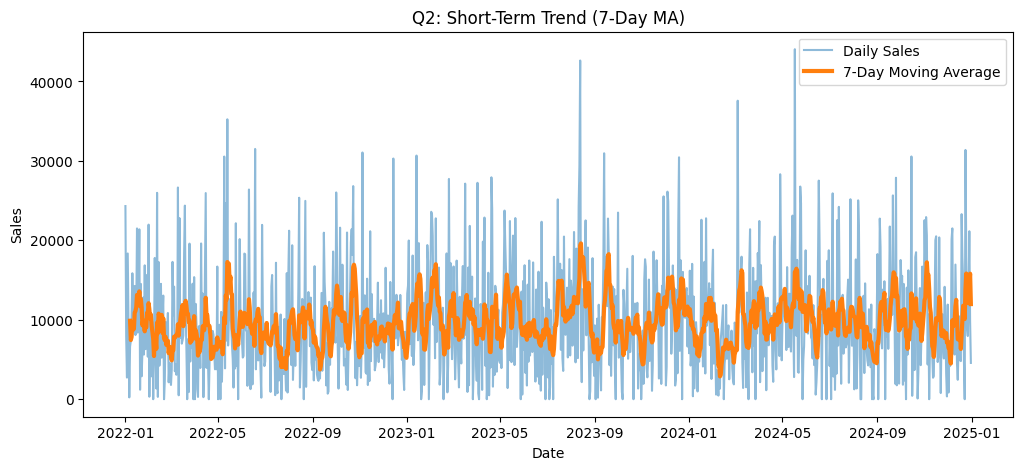

In [45]:
#calculating 7day moving average
daily_df['MA_7'] = daily_df['Sales'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_df.index, daily_df['Sales'], label='Daily Sales', alpha=0.5)
plt.plot(daily_df.index, daily_df['MA_7'], label='7-Day Moving Average', linewidth=3)
plt.legend()
plt.title("Q2: Short-Term Trend (7-Day MA)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**interpretation**
the 7day moving average traces the daily data much more tightly than the 30day MA. it reveals significant short-term volatility, suggesting that sales momentum shifts rapidly from week to week. This indicates that recent past performance(the last few days days) will likely be strong predictor for immidiate future sales.

#Question 3:

**Does sales volume from the previous day directly affect today's sales?**

we will create lag1 feature(yesterdays sales) and check its correlation with today's sales

correlatioon between Sales and lag 1:


,Sales,lag_1
Sales,1.000000,0.018281
lag_1,0.018281,1.000000


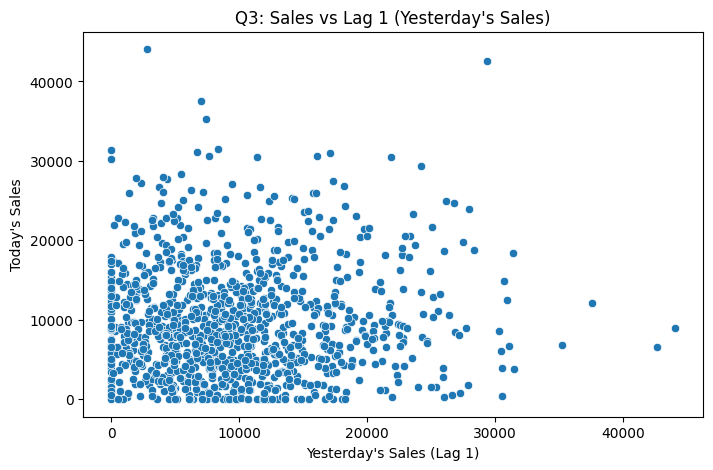

In [50]:
#creating lag1 feature
daily_df['Lag_1'] = daily_df['Sales'].shift(1)

print('correlatioon between Sales and lag 1:')
display(daily_df[['Sales', 'lag_1']].corr())

plt.figure(figsize=(8,5))
sns.scatterplot(x=daily_df['Lag_1'], y=daily_df['Sales'])
plt.title("Q3: Sales vs Lag 1 (Yesterday's Sales)")
plt.xlabel("Yesterday's Sales (Lag 1)")
plt.ylabel("Today's Sales")
plt.show()



**Interpretation**
the scatter plot shows a dense, somewhat diffuse cloud of points. Based on the visualization, the linear relationship between yesterday's sales and today's sales is weak. a high sales day yesterday does not guarantee a high sales day today. indicating that the day to day sales are fairly independent of theor immidiate predecessor. so No the volume from the previous day dpes not directly affect today's sales

#Question 4

**Is there a weekly seasonality effect where sales from exactly one week ago correlate with today's sales?**

we will use lag_7 to compare todays's sales with the sales on the exact same day last week

Correlation between sales and lag_7:


,Sales,Lag_7
Sales,1.00000,0.00444
Lag_7,0.00444,1.00000


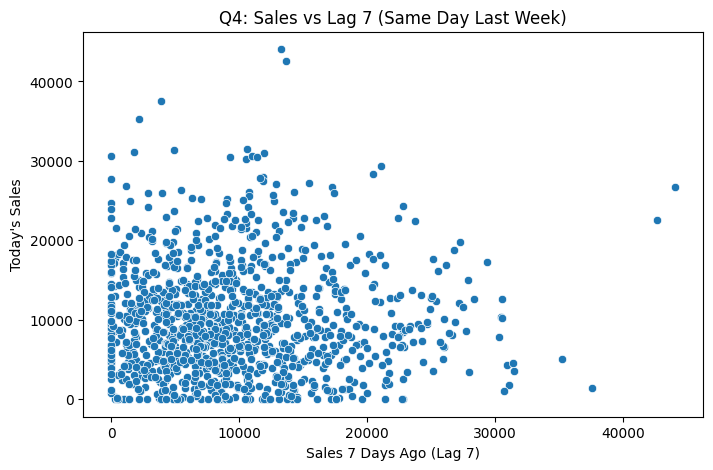

In [55]:
#creating lag_7 feature
daily_df['Lag_7'] = daily_df['Sales'].shift(7)

print("Correlation between sales and lag_7:")
display(daily_df[['Sales', 'Lag_7']].corr())

plt.figure(figsize=(8,5))
sns.scatterplot(x=daily_df['Lag_7'], y=daily_df['Sales'])
plt.title("Q4: Sales vs Lag 7 (Same Day Last Week)")
plt.xlabel("Sales 7 Days Ago (Lag 7)")
plt.ylabel("Today's Sales")
plt.show()


**Interpretation:**
similar to lag_1, the lag_7 scatter plot does not shpw a tight, libnear, or upward trend. whi;e there might be slight undwerlying weekly patterns, the simple 1-1 correlation between specific day and exact day a week prior is noisy. this suggeste the model will need combinations of features rather than relying on exact lagged feature

#Question 5

**How does the volatility of sales change over time?**

to understand business stability, we will look at the 30-day rolling standard deviation.

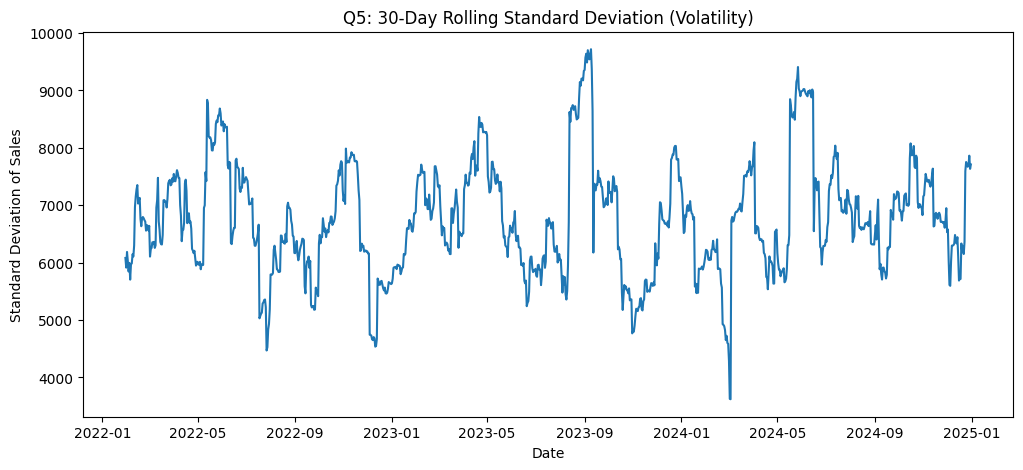

In [56]:
#calculating the 30-day rolling standard deviation
daily_df['Rolling_Std_30'] = daily_df['Sales'].rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(daily_df.index, daily_df['Rolling_Std_30'])
plt.title("Q5: 30-Day Rolling Standard Deviation (Volatility)")
plt.xlabel("Date")
plt.ylabel("Standard Deviation of Sales")
plt.show()


**Interpretation**:

the volatility chartshows distinct spikes and drops. periods with high rolling standard deviation indicate eratic sales behaviour(maybe, during the holiday seasons or aggresive marketing campaigns where daily totals swing wildly,) dips in the graph represent periods of highly consistent, predictable sales.

#Training a Model

We will use random forect regressor to predict daily sales based on our engineered time series features (lags and moving averages). we will run the baseline experiment and the hyperparameter-tuned experiment.

In [59]:
#dropping the rows with NAN values created by shifts and lolling windows
model_df = daily_df.dropna(subset=['Lag_1','Lag_7','MA_7','MA_30'])

#defining the features and target
features=['Lag_1','Lag_7','MA_7','MA_30' ]
X=model_df[features]
y=model_df['Sales']

#time-series safe train-test split the data by 80/20(chronologcally)
train_size=int(len(model_df) * 0.8)
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (853, 4)
Test shape: (214, 4)


In [60]:
#experiment 1: Baseline Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
rf_pred_base = rf_base.predict(X_test)

print('training baseline random forest complete')

In [65]:
# Baseline Metrics
mae_base = mean_absolute_error(y_test, rf_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, rf_pred_base))
r2_base = r2_score(y_test, rf_pred_base)

print("Baseline random forest - experiment 1")
print('MAE:', mae_base)
print('RMSE:', rmse_base)
print('R2:', r2_base)


Baseline random forest - experiment 1
MAE: 5374.031355140187
RMSE, 6790.198171955414
R2: 0.01901973238968968


### Interpretation: experiment 1 (baseline random forest)

**objective:** To establish a baseline performance using our standard time-series features (`Lag_1`, `Lag_7`, `MA_7`, `MA_30`) with a default Random Forest model.

**results breakdown:**
* **MAE (~5,374):** on an average day, our baseline prediction is off by roughly 5,374 units/dollars. Given our overall daily sales average is ~$9,733, this is a substantial margin of error.
* **RMSE (~6,790):** Because RMSE penalizes large errors more heavily than MAE, this high value indicates that the model is occasionally making massive miscalculations (likely missing the extreme sales spikes entirely).
* **R² (~0.019):** An R² of 0.019 means this baseline model only explains about **1.9%** of the variance in our daily sales. It is performing only slightly better than a model that simply guesses the historical average every single day.

**Conclusion:** Historical lags and moving averages, combined with default model parameters, are severely under-equipped to handle the extreme volatility of this dataset.

In [64]:
#experiment 2: tuned random Forest
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_pred_tuned = rf_tuned.predict(X_test)

print('training tuned random forest complete')



training tuned random forest complete


In [66]:
# tuned Metrics
mae_tuned = mean_absolute_error(y_test, rf_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, rf_pred_tuned))
r2_tuned = r2_score(y_test, rf_pred_tuned)

print('tuned random forest- experiment 2')
print('MAE:', mae_tuned)
print('RMSE:', rmse_tuned)
print('R2:', r2_tuned)

tuned random forest- experiment 2
MAE: 5276.847028131684
RMSE: 6644.365578005272
R2: 0.06070413118764961


### Interpretation: experiment 2 (tuned random rorest)

**objective:** To determine if optimizing the model's hyperparameters (like `max_depth` and `n_estimators`) can help it better capture the underlying patterns in our existing time-series features.

**results breakdown:**
* **Improved metrics:** The tuning was mathematically successful. The MAE dropped to ~5,276, the RMSE dropped to ~6,644, and the R² tripled to **0.060 (6.0%)**.

**Conclusion:** While hyperparameter tuning maximized the predictive power of our current features, an R² of 6% confirms that historical sales data alone does not contain the necessary signals to predict the extreme, erratic spikes in this business's sales cycle.

#**Comparing Predictions to Actuals and Feature Importance**

Let's visualize how well our tuned model predicted the test set, and which features it relied on the most.

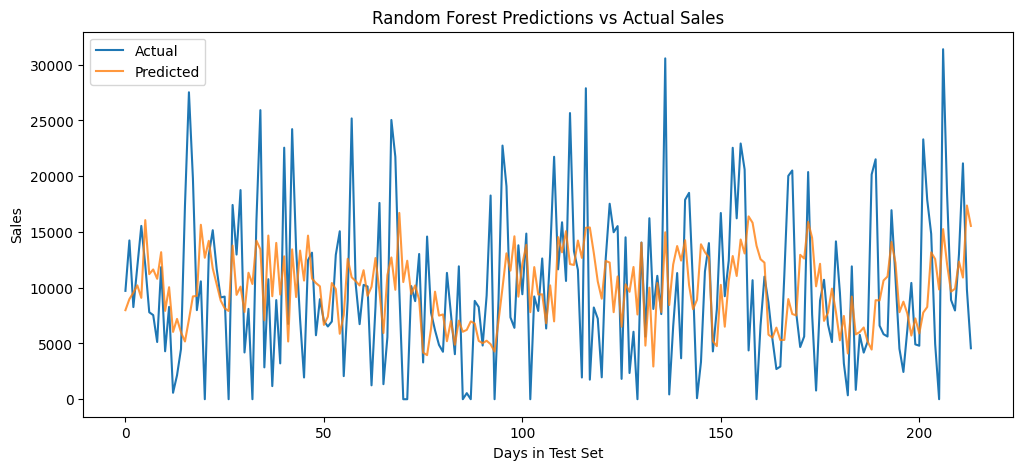

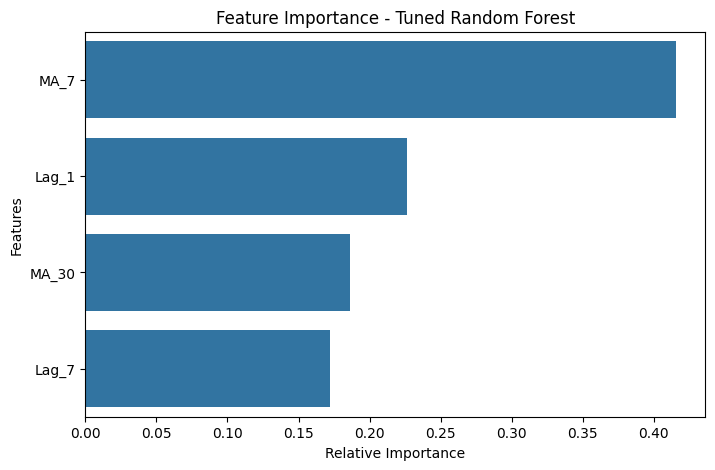

In [67]:
# Plotting Predictions vs Actuals (using Tuned model)
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", linewidth=1.5)
plt.plot(rf_pred_tuned, label="Predicted", alpha=0.8, linewidth=1.5)
plt.legend()
plt.title("Random Forest Predictions vs Actual Sales")
plt.xlabel("Days in Test Set")
plt.ylabel("Sales")
plt.show()

# Feature Importance from Tuned Model
feature_importance = pd.Series(
    rf_tuned.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()

Visual Context (Predictions vs. Actual):

 Despite the improvement, looking at the line chart reveals the core issue. The actual data (blue line) features extreme, erratic spikes reaching up to 30,000. Our tuned model (orange line) fails to predict these peaks and valleys, instead playing it safe by predicting a "middle band" between 5,000 and 15,000.
Feature Importance: The model relies overwhelmingly on MA_7 (the 7-day moving average) to make these safe, middle-band predictions.

#Experiment 3: Adding Calendar Features

since our previous models struggled to capture the extreme variance in daily sales using only historical lags, we will introduce calendar features. By extracting the DayOfWeek (0 = Monday, 6 = Sunday) and Month (1-12) directly from the date index, we can help the Random Forest understand if certain days (like weekends) or certain months (like holiday seasons) naturally drive higher sales.


In [68]:
#feature Engineering: Adding Calendar Features
daily_df['DayOfWeek'] = daily_df.index.dayofweek
daily_df['Month'] = daily_df.index.month

#re-drop NaNs just to be safe, though date extraction doesn't create NaNs
model_df_v2 = daily_df.dropna(subset=['Lag_1','Lag_7','MA_7','MA_30'])

#define the NEW feature set
features_v2 = ['Lag_1', 'Lag_7', 'MA_7', 'MA_30', 'DayOfWeek', 'Month']
X_v2 = model_df_v2[features_v2]
y_v2 = model_df_v2['Sales']

# train-Test Split (Re-using chronological split)
train_size = int(len(model_df_v2) * 0.8)
X_train_v2 = X_v2.iloc[:train_size]
X_test_v2 = X_v2.iloc[train_size:]
y_train_v2 = y_v2.iloc[:train_size]
y_test_v2 = y_v2.iloc[train_size:]

In [70]:
#train the Model (Using our tuned hyperparameters)
rf_calendar = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_calendar.fit(X_train_v2, y_train_v2)
rf_pred_calendar = rf_calendar.predict(X_test_v2)

# evaluate
mae_calendar = mean_absolute_error(y_test_v2, rf_pred_calendar)
rmse_calendar = np.sqrt(mean_squared_error(y_test_v2, rf_pred_calendar))
r2_calendar = r2_score(y_test_v2, rf_pred_calendar)

print('Random Forest with Calendar Features')
print('MAE:', mae_calendar)
print('RMSE:', rmse_calendar)
print('R2:', r2_calendar)

Random Forest with Calendar Features
MAE: 5320.313354257618
RMSE: 6641.781655164575
R2: 0.06143455340499526


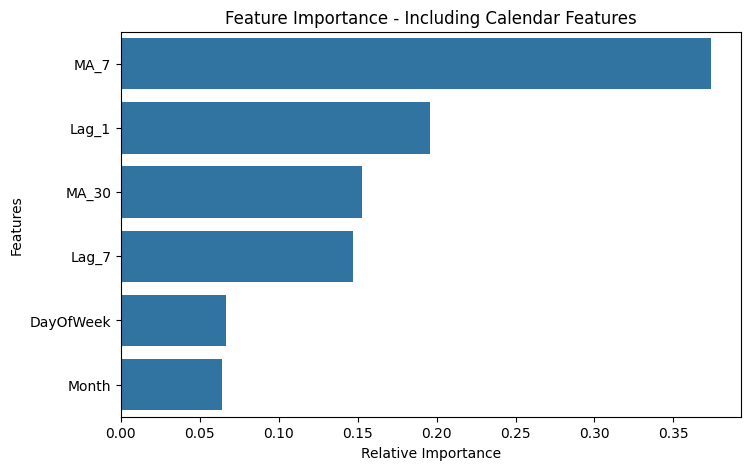

In [76]:
# if the new features changed the feature importance ranking
feature_importance_v2 = pd.Series(
    rf_calendar.feature_importances_,
    index=features_v2
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance_v2.values, y=feature_importance_v2.index)
plt.title("Feature Importance - Including Calendar Features")
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()

### Interpretation: Experiment 3 (adding calendar features)

**Objective:** To test the hypothesis that the massive sales spikes are seasonal. By adding explicit calendar features (`DayOfWeek` and `Month`), we aimed to see if the model could learn that certain days (like weekends) or certain months (like holidays) consistently drive higher sales.

**results breakdown:**
* **Stagnant Performance:** The performance metrics remained virtually unchanged. The R² increased by a negligible fraction (from 0.060 to **0.061**), the RMSE dropped marginally, and the MAE actually increased slightly to ~5,320.
* **feature importance insights:** The updated feature importance chart acts as a "smoking gun." The newly added `DayOfWeek` and `Month` features ranked as the absolute lowest contributors to the model's decisions.

**final conclusion:**
This experiment proves that the extreme sales volatility in this dataset is actually not driven by strict calendar seasonality. The massive spikes in sales do not consistently happen on specific days of the week or specific months. Instead, the variance is almost certainly driven by unpredictable, external business events such as random flash sales, unannounced marketing campaigns, bulk B2B orders, or viral social media pushes. Future forecasting models for this business must incorporate external datasets (like a promotional calendar or marketing spend) to achieve high accuracy.

In [75]:
#Experiment Table
results = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (Tuned lags)",
        "Random Forest (Calendar Features)"
        ],

    "MAE": [mae_base, mae_tuned, mae_calendar],
    "RMSE": [rmse_base, rmse_tuned, rmse_calendar],
    "R2": [r2_base, r2_tuned, r2_calendar]
})

display(results)

,Model,MAE,RMSE,R2
0,Random Forest (Baseline),5374.031355,6790.198172,0.019020
1,Random Forest (Tuned lags),5276.847028,6644.365578,0.060704
2,Random Forest (Calendar Features),5320.313354,6641.781655,0.061435


### Final Experiment Summary & Conclusion

**Table vverview:**
The table compares the performance across our three iterations or experoiments of the Random Forest model. to put these errors into perspective, our dataset has an **average daily sales volume of ~$9,733**, but then there id extreme volatility (frequent drops to 0 and massive spikes over 30,000).

 **Experiment 1: Baseline Model**
   **Performance:**
   
    poor. The model relies on default parameters and basic lags. It misses predictions by an average of ~$5,374 (MAE) per day.
   **variance explanation** The $R^2$ of **0.019 (1.9%)** shows that baseline moving averages barely explain any of the daily variance.

 **Experiment 2: tuned lags**

   **Performance:**
   
   hyperparameter tuning (adjusting tree depth, estimators,) successfully optimized the model. The MAE dropped to ~$5,276 and RMSE improved to ~6,644.
   **varinace explaination:** The $R^2$ jumped to **0.060 (6.0%)**. While this is a 3x improvement over the baseline, an overall score of 6% remains very low, indicating that historical lags alone cannot predict the massive spikes in this specific dataset.

 **Experiment 3: calendar features**

   **Performance:**
   
    adding explicit seasonality (`DayOfWeek` and `Month`) resulted in almost no change. The $R^2$ barely moved to **0.061 (6.1%)**, and the MAE actually increased slightly to ~$5,320.
   **meaning:** The Random Forest largely ignored the calendar features, proving that the extreme sales spikes are **not seasonal** (therefore, they do not consistently happen on specific days of the week or specific holiday months).

  **Final Conclusion for Task 1:**

  
  Through exploratory data analysis and iterative machine learning experiments, we discovered that this e-commerce dataset is highly volatile. although we successfully engineered features and tuned a model to capture the baseline rolling average of sales, time-series data alone is insufficient to forecast the extreme peaks and valleys. in ordder build a highly accurate forecasting model for this specific business, we would need to merge external business context, such as a promotional calendar, marketing spend, or discount code activations, to explain the irregular surges in sales.